# MC-simulering v3: Stockpicking-skicklighet × Viktning × Portföljstorlek

Tre diskreta dimensioner varieras:
- **Bias**: `0.0 → 1.0` — graden av skicklighet i stockpicking (0 = slumpmässigt, 1 = alltid bästa halvan)
- **Viktning**: `equal`, `cap`, `risk_parity` (inverterad volatilitet)
- **Portföljstorlek**: 10, 50, 100 aktier

Vid varje rebalanseringspunkt delas universumet i topp- och bottenhälft baserat på **framtida** avkastning (fusk framåt). `bias=0` innebär 50/50-urval ur de två halvorna (= slump), `bias=1` innebär urval enbart ur den bättre halvan.

Portföljerna rebalanseras årsvis med max 30 % omsättning per period.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from functools import lru_cache


In [55]:
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
try:
    plt.style.use('kvartil.mplstyle')
except Exception:
    pass


## 1. Ladda data


In [56]:
DATAFOLDER = r'analysdata'

AVKASTNINGAR = pd.read_pickle(DATAFOLDER + r'\avkastningar.pkl')
VIKTER       = pd.read_pickle(DATAFOLDER + r'\vikter.pkl')

UNIVERSE = VIKTER.columns.intersection(AVKASTNINGAR.columns)
AVKASTNINGAR = AVKASTNINGAR[UNIVERSE]
VIKTER       = VIKTER[UNIVERSE]

print(f'Universum : {len(UNIVERSE)} aktier')
print(f'Period    : {AVKASTNINGAR.index[0].date()} -> {AVKASTNINGAR.index[-1].date()}')
print(f'Dagar     : {len(AVKASTNINGAR)}')


Universum : 1253 aktier
Period    : 2005-03-24 -> 2025-03-21
Dagar     : 5090


## 2. Hjälpfunktioner


In [57]:
def get_kfs(rets, benchrets, periods_yr=12, monthly_vol=False):
    rets_m = rets
    benchrets_m = (
        (1 + benchrets)
        .cumprod()
        .resample('ME')
        .last()
        .pct_change()
        .dropna()
        .reindex(rets_m.index)
    )
    if len(rets) > len(rets_m) * 12:
        yrs = (rets.index[-1] - rets.index[0]) / np.timedelta64(365, 'D')
    else:
        yrs = len(rets_m) / 12
    dd = 1 - (1 + rets).cumprod() / (1 + rets).cumprod().expanding().max()
    yr = np.power((1 + rets).cumprod().iloc[-1], 1 / yrs) - 1
    if monthly_vol:
        yv = rets_m.std() * np.sqrt(12)
    else:
        yv = rets.std() * np.sqrt(periods_yr)
    max_dd          = dd.max()
    mean_dd         = dd.mean()
    ir              = yr / yv
    beta            = rets_m.corrwith(benchrets_m) * rets_m.std() / benchrets_m.std()
    downside_capture = rets_m[benchrets_m < 0].mean() / benchrets_m[benchrets_m < 0].mean()
    upside_capture   = rets_m[benchrets_m > 0].mean() / benchrets_m[benchrets_m > 0].mean()
    share_up_month  = (rets_m > 0).mean()
    avg_down_month  = rets_m[rets_m < 0].mean()
    avg_up_month    = rets_m[rets_m > 0].mean()
    rets_0          = rets.sub(rets.mean())
    upside_vol      = rets_0[rets_0 > 0].std() * np.sqrt(periods_yr)
    downside_vol    = rets_0[rets_0 < 0].std() * np.sqrt(periods_yr)
    batting_average = (rets_m.sub(benchrets_m, axis=0) >= 0.000001).mean()
    var95           = rets_m.quantile(0.05)
    var99           = rets_m.quantile(0.01)
    cvar            = rets_m[rets_m < var95].mean()
    skew            = rets_m.skew()
    kurtosis        = rets_m.kurtosis()
    sortino_ratio   = yr / downside_vol
    calmar_ratio    = yr / abs(max_dd)

    if type(yr) == pd.Series:
        return pd.concat(
            {
                'Return': yr, 'Vol': yv, 'Max DrawDown': max_dd,
                'Information Ratio': ir, 'Beta': beta,
                'Downside Capture': downside_capture, 'Upside capture': upside_capture,
                'Share up month': share_up_month, 'Avg. down-month': avg_down_month,
                'Avg. up-month': avg_up_month, 'Downside vol.': downside_vol,
                'Upside vol.': upside_vol, 'Batting average': batting_average,
                'VaR 95%': var95, 'VaR 99%': var99, 'Conditional VaR (5%)': cvar,
                'Skew': skew, 'Kurtosis': kurtosis,
                'Sortinokvot': sortino_ratio, 'Calmarkvot': calmar_ratio,
            },
            axis=1,
        )
    else:
        return pd.Series(
            {
                'Return': yr, 'Vol': yv, 'Max DrawDown': max_dd,
                'Information Ratio': ir, 'Beta': beta,
                'Downside Capture': downside_capture, 'Upside capture': upside_capture,
                'Share up month': share_up_month, 'Avg. down-month': avg_down_month,
                'Avg. up-month': avg_up_month, 'Downside vol.': downside_vol,
                'Upside vol.': upside_vol, 'Batting average': batting_average,
                'VaR 95%': var95, 'VaR 99%': var99, 'Conditional VaR (5%)': cvar,
                'Skew': skew, 'Kurtosis': kurtosis,
                'Sortinokvot': sortino_ratio, 'Calmarkvot': calmar_ratio,
            }
        )


In [58]:
def get_forward_partition(date, next_date):
    """
    Delar upp universumet i topp- och bottenhälft baserat på framtida avkastning
    (fuskar framåt — next_date är nästa rebalanseringstillfälle).
    Returnerar (top_half, bot_half) som listor av ticker-strängar.
    """
    # Kumulativ avkastning från date till next_date
    fwd = AVKASTNINGAR.loc[date:next_date].add(1).prod(min_count=1) - 1
    fwd = fwd.dropna()

    # Begränsa till aktier med tillräcklig historik vid date
    window = AVKASTNINGAR.loc[:date].iloc[-252:]
    active = window.columns[window.count() >= 252 * 0.8]
    fwd = fwd.reindex(active).dropna()

    median_ret = fwd.median()
    top_half = fwd[fwd >= median_ret].index.tolist()
    bot_half = fwd[fwd < median_ret].index.tolist()
    return top_half, bot_half


def get_bias_probs(top_half, bot_half, bias):
    """
    Samplingssannolikheter baserade på framtida partition och bias-nivå.
    bias=0  → lika sannolikhet för alla aktier (= slumpmässigt)
    bias=1  → enbart aktier ur topphälvan kan väljas
    Aktier i topphälvan får vikt (0.5 + bias*0.5)/n_top,
    aktier i bottenhälvan får vikt (0.5 - bias*0.5)/n_bot.
    """
    n_top = len(top_half)
    n_bot = len(bot_half)
    top_set = set(top_half)

    w_top = (0.5 + bias * 0.5) / n_top if n_top > 0 else 0.0
    w_bot = (0.5 - bias * 0.5) / n_bot if n_bot > 0 else 0.0

    all_stocks = top_half + bot_half
    weights = pd.Series(
        [w_top if s in top_set else w_bot for s in all_stocks],
        index=all_stocks,
        dtype=float,
    )
    total = weights.sum()
    if total > 0:
        return weights / total
    return pd.Series(1.0 / len(all_stocks), index=all_stocks)


def get_weights_v2(tickers, date, weighting):
    """Portföljvikter: equal | cap | risk_parity (inverterad volatilitet)."""
    tickers = list(tickers)
    n = len(tickers)

    if weighting == 'equal':
        return pd.Series(1.0 / n, index=tickers)

    elif weighting == 'cap':
        idx = VIKTER.index.get_indexer([date], method='nearest')[0]
        w = VIKTER.iloc[idx][tickers].fillna(0).clip(lower=0)
        s = w.sum()
        return w / s if s > 0 else pd.Series(1.0 / n, index=tickers)

    elif weighting == 'risk_parity':
        window = AVKASTNINGAR.loc[:date].iloc[-252:]
        vols = window[tickers].std()
        inv_vol = (1.0 / vols).replace([np.inf, -np.inf], np.nan).fillna(0)
        s = inv_vol.sum()
        return inv_vol / s if s > 0 else pd.Series(1.0 / n, index=tickers)

    else:
        raise ValueError(f'Okänd viktning: {weighting}')

In [59]:
def draw_initial_holdings(top_half, bot_half, pf_size, bias, rng):
    """Drar startportfölj givet framtida partition och bias."""
    all_stocks = top_half + bot_half
    if len(all_stocks) < pf_size:
        raise ValueError(
            f'För få aktiva aktier ({len(all_stocks)}) för pf_size={pf_size}'
        )
    probs = get_bias_probs(top_half, bot_half, bias)
    chosen = rng.choice(probs.index, size=pf_size, replace=False, p=probs.values)
    return list(chosen)


def rebalance_holdings(date, prev_holdings, top_half, bot_half, pf_size, bias, rng,
                       max_turnover=0.3):
    """
    Uppdaterar innehav med begränsad omsättning.
    Både keep- och nytt-picks-steget är stokastiska och viktas med bias-sannolikheterna
    så att effekten av bias graderas kontinuerligt (undviker deterministisk step-funktion).
    """
    all_stocks = set(top_half + bot_half)
    if len(all_stocks) < pf_size:
        return prev_holdings

    probs = get_bias_probs(top_half, bot_half, bias)
    still_active = [t for t in prev_holdings if t in all_stocks]

    n_forced = pf_size - len(still_active)
    n_swap   = max(int(np.floor(pf_size * max_turnover)), n_forced)
    n_keep   = pf_size - n_swap

    # Keep-steget: stokastiskt urval viktat på bias-sannolikheter
    # (deterministisk sort+topp-k ger step-funktion vid bias=0 → identisk effekt för alla bias>0)
    if still_active and n_keep > 0:
        active_probs = probs.reindex(still_active, fill_value=0)
        s = active_probs.sum()
        if s > 0:
            active_probs = active_probs / s
        else:
            active_probs = pd.Series(1.0 / len(still_active), index=still_active)
        keep_n = min(n_keep, len(still_active))
        keep = list(rng.choice(still_active, size=keep_n, replace=False, p=active_probs.values))
    else:
        keep = []

    # Dra nya aktier bland kandidater (ej redan kvar)
    candidates = probs.index.difference(keep)
    cand_probs = probs.reindex(candidates, fill_value=0)
    s = cand_probs.sum()
    cand_probs = cand_probs / s if s > 0 else pd.Series(1.0 / len(candidates), index=candidates)

    n_new = min(pf_size - len(keep), len(candidates))
    new_picks = rng.choice(candidates, size=n_new, replace=False, p=cand_probs.values)
    return keep + list(new_picks)


def simulate_one_portfolio(bias, weighting, pf_size, seed, rebal_dates,
                           max_turnover=0.3):
    """Simulerar en portfölj med periodisk ombalansering. Returnerar dagliga avkastningar."""
    rng = np.random.default_rng(seed)

    top_half, bot_half = get_forward_partition(rebal_dates[0], rebal_dates[1])
    holdings = draw_initial_holdings(top_half, bot_half, pf_size, bias, rng)
    weights  = get_weights_v2(holdings, rebal_dates[0], weighting)

    all_returns = []

    for i in range(len(rebal_dates) - 1):
        t0 = rebal_dates[i]
        t1 = rebal_dates[i + 1]

        period_rets = AVKASTNINGAR.loc[t0:t1, holdings].fillna(0)
        w_aligned   = weights.reindex(period_rets.columns, fill_value=0)
        pf_rets     = period_rets.mul(w_aligned).sum(axis=1)
        all_returns.append(pf_rets.iloc[1:])

        if i < len(rebal_dates) - 2:
            next_t = rebal_dates[i + 2]
            top_half, bot_half = get_forward_partition(t1, next_t)
            holdings = rebalance_holdings(
                t1, holdings, top_half, bot_half, pf_size, bias, rng, max_turnover
            )
            weights = get_weights_v2(holdings, t1, weighting)

    combined = pd.concat(all_returns).sort_index()
    return combined.groupby(level=0).first()


def run_mc_simulation(bias, weighting, pf_size, num_runs, rebal_dates,
                      max_turnover=0.3):
    """Kör num_runs simuleringar och returnerar KFS-metrics per run."""
    index_rets = (
        VIKTER.mul(AVKASTNINGAR).sum(axis=1)
        .add(1).cumprod().resample('ME').last()
        .pct_change(fill_method=None).replace(0, np.nan).dropna()
    )

    results = {}
    for i in range(num_runs):
        try:
            daily = simulate_one_portfolio(
                bias, weighting, pf_size, seed=i,
                rebal_dates=rebal_dates, max_turnover=max_turnover,
            )
            monthly = (
                daily.add(1).cumprod().resample('ME').last()
                .pct_change(fill_method=None).replace(0, np.nan).dropna()
            )
            bench = index_rets.reindex(monthly.index)
            results[i] = get_kfs(monthly.to_frame(), bench.to_frame()).loc[0]
        except Exception:
            pass

    return pd.DataFrame(results)

## 3. Parametergrid & simulering


In [94]:
# === Parametergrid ===
MC_BIASES        = [round(x, 2) for x in np.arange(0.21, 0.31, 0.01)]  # 0=slump, 1=perfekt stockpicker
MC_WEIGHTINGS    = ['equal', 'cap', 'risk_parity']
MC_PF_SIZES      = [5, 10, 20, 100]
MC_NUM_RUNS      = 1000
MC_MAX_TURNOVER  = 0.3

MC_START       = pd.Timestamp('2015-01-01')
MC_END         = pd.Timestamp('2025-01-01')
MC_REBAL_DATES = pd.date_range(MC_START, MC_END, freq='YS').tolist()

RESULTATFOLDER = r'analysresultat'

n_combos = len(MC_BIASES) * len(MC_WEIGHTINGS) * len(MC_PF_SIZES)
print(f'Rebalanseringstillfällen : {len(MC_REBAL_DATES)}')
print(f'Bias-nivåer              : {MC_BIASES}')
print(f'Parameterkombinationer   : {n_combos}  ({len(MC_BIASES)} bias × {len(MC_WEIGHTINGS)} weighting × {len(MC_PF_SIZES)} pf_size)')
print(f'Totalt MC-körningar      : {n_combos * MC_NUM_RUNS:,}')

Rebalanseringstillfällen : 11
Bias-nivåer              : [np.float64(0.21), np.float64(0.22), np.float64(0.23), np.float64(0.24), np.float64(0.25), np.float64(0.26), np.float64(0.27), np.float64(0.28), np.float64(0.29), np.float64(0.3)]
Parameterkombinationer   : 120  (10 bias × 3 weighting × 4 pf_size)
Totalt MC-körningar      : 120,000


In [95]:
# === Kör simulering och spara ===
MC_RESULT_FILE = 'result_mc_0419b.pkl'
MC_SAVE_PATH   = RESULTATFOLDER + rf'\{MC_RESULT_FILE}'

answer = input(f'⚠️  Kör ny MC-simulering och spara {MC_RESULT_FILE}? (ja/nej): ')

if answer.strip().lower() != 'ja':
    print('❌ Ingen simulering körd.')
else:
    mc_raw = {}
    combos = list(product(MC_BIASES, MC_WEIGHTINGS, MC_PF_SIZES))

    for i, (bias, wgt, sz) in enumerate(combos):
        print(f'  [{i+1}/{len(combos)}] bias={bias:<4} wgt={wgt:<12} sz={sz:>3}', end='\r')
        mc_raw[(bias, wgt, sz)] = run_mc_simulation(
            bias, wgt, sz,
            num_runs=MC_NUM_RUNS,
            rebal_dates=MC_REBAL_DATES,
            max_turnover=MC_MAX_TURNOVER,
        )

    frames = []
    for (bias, wgt, sz), df in mc_raw.items():
        df = df.copy()
        df.index = pd.MultiIndex.from_arrays(
            [[bias]*len(df), [wgt]*len(df), [sz]*len(df), df.index],
            names=['bias', 'weighting', 'pf_size', 'metric']
        )
        frames.append(df)
    mc_result = pd.concat(frames)
    mc_result.to_pickle(MC_SAVE_PATH)
    print(f'\n✅ Sparat till: {MC_SAVE_PATH}')

C:\Users\JonasAnderssonTuomaa\AppData\Local\Temp\ipykernel_16452\2358250179.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()


C:\Users\JonasAnderssonTuomaa\AppData\Local\Temp\ipykernel_16452\2358250179.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()


  [120/120] bias=0.3  wgt=risk_parity  sz=100
✅ Sparat till: analysresultat\result_mc_0419b.pkl


In [42]:
# vid avgryt
frames = []
for (bias, wgt, sz), df in mc_raw.items():
    df = df.copy()
    df.index = pd.MultiIndex.from_arrays(
        [[bias]*len(df), [wgt]*len(df), [sz]*len(df), df.index],
        names=['bias', 'weighting', 'pf_size', 'metric']
    )
    frames.append(df)
mc_result = pd.concat(frames)

In [26]:
MC_SAVE_PATH = 'analysresultat\\res_bias_pf.pkl'

In [27]:
mc_result.to_pickle(MC_SAVE_PATH)

## 4. Ladda resultat


In [101]:
# === Ladda sparad resultatfil ===
MC_RESULT_FILE = 'result_mc_0419.pkl'
mc_result = pd.read_pickle(RESULTATFOLDER + rf'\{MC_RESULT_FILE}')

index_rets = (
    VIKTER.mul(AVKASTNINGAR).sum(axis=1)
    .add(1).cumprod().resample('ME').last()
    .pct_change(fill_method=None).replace(0, np.nan).dropna()
)
bench_kfs = get_kfs(
    index_rets.loc[MC_START:MC_END].to_frame(),
    index_rets.loc[MC_START:MC_END].to_frame()
).loc[0]

print('Resultat laddade:', mc_result.shape)
print('Nivåer:', mc_result.index.names)
print('Benchmark Return:', round(bench_kfs['Return'], 4))

Resultat laddade: (7440, 1000)
Nivåer: ['bias', 'weighting', 'pf_size', 'metric']
Benchmark Return: 0.1045


In [102]:
MC_BIASES        = list(mc_result.index.levels[0])
MC_WEIGHTINGS    = list(mc_result.index.levels[1])
MC_PF_SIZES      = list(mc_result.index.levels[2])

## 5. Analys


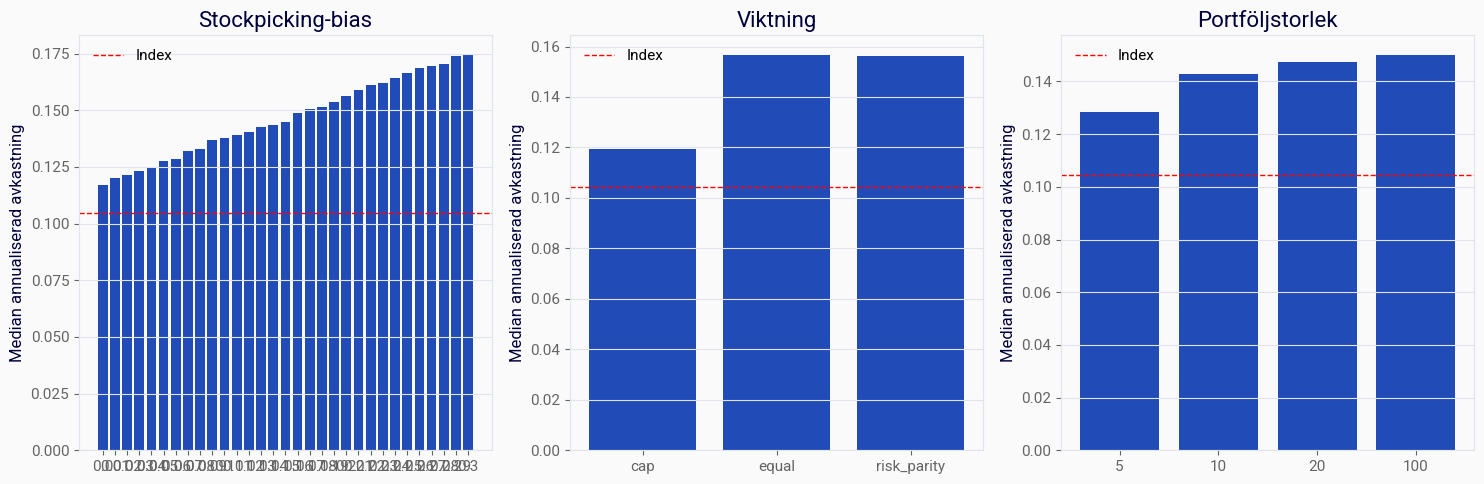

In [103]:
# === Median-avkastning per dimension ===
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric = 'Return'

dims = [
    ('bias',      'Stockpicking-bias',  MC_BIASES),
    ('weighting', 'Viktning',           MC_WEIGHTINGS),
    ('pf_size',   'Portföljstorlek',    MC_PF_SIZES),
]

for ax, (level, label, order) in zip(axes, dims):
    data = mc_result.xs(metric, level='metric')
    medians = data.groupby(level=level).median().median(axis=1)
    medians = medians.reindex([str(o) if isinstance(o, int) else o for o in order])
    if medians.isna().all():
        medians = data.groupby(level=level).median().median(axis=1)
    ax.bar(medians.index.astype(str), medians.values)
    ax.axhline(bench_kfs[metric], color='red', linestyle='--', label='Index')
    ax.set_title(label)
    ax.set_ylabel('Median annualiserad avkastning')
    ax.legend()

plt.tight_layout()
plt.show()

In [104]:
MC_BIASES_PLOT = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

sz_focus = 20  (tillgängliga pf_sizes: [5, 10, 20, 100])


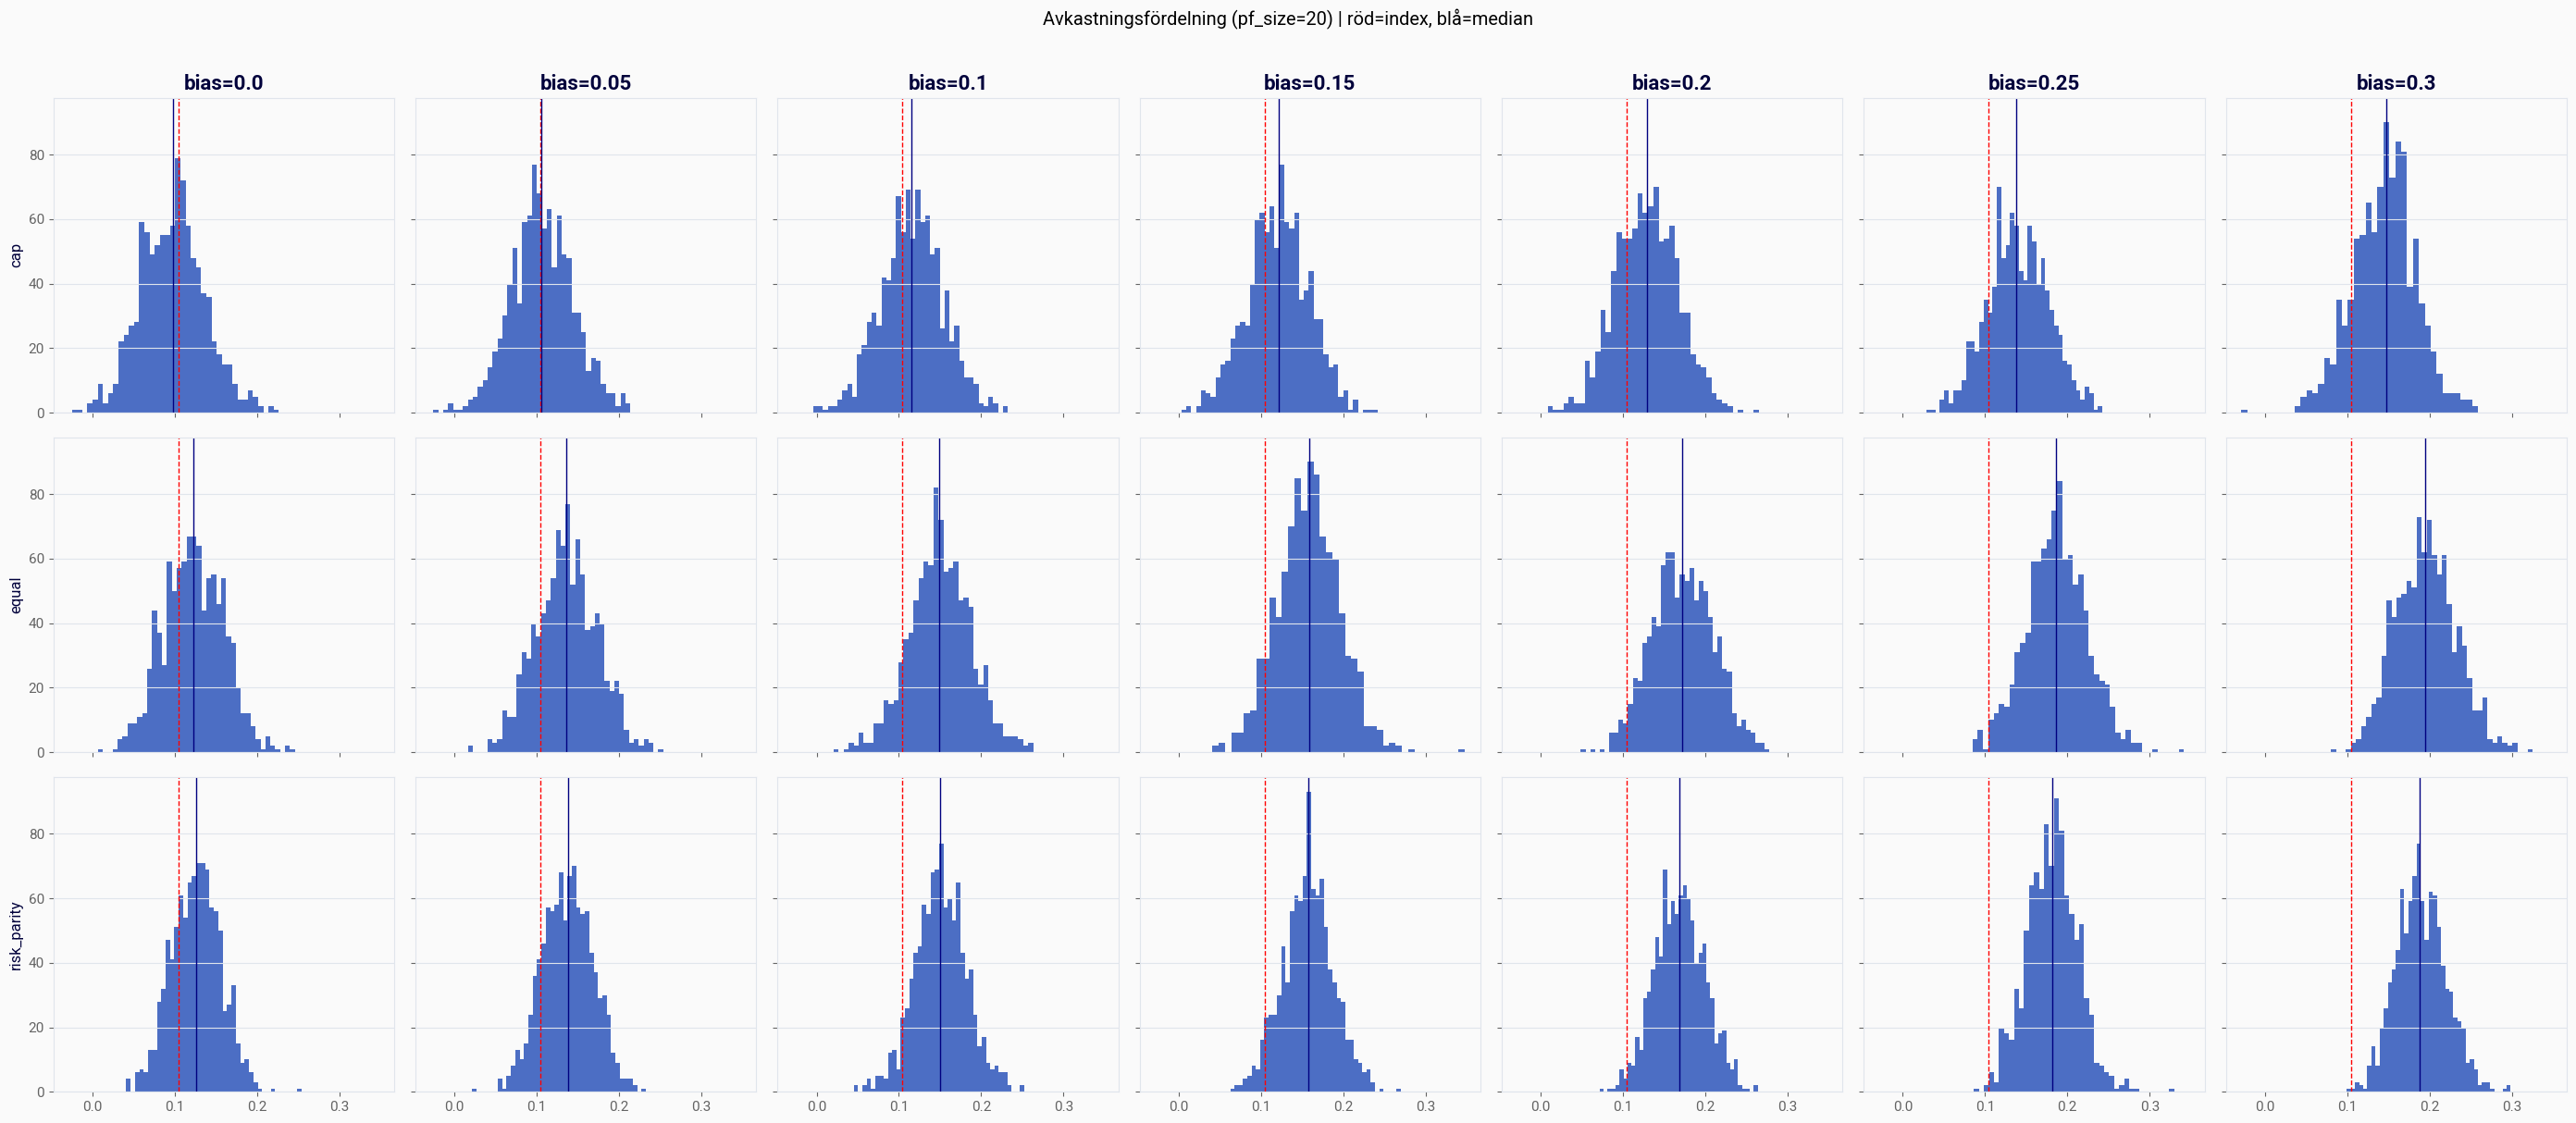

In [105]:
# === Fördelning av avkastning per bias × viktning ===
from scipy.stats import gaussian_kde

metric = 'Return'

# sz_focus: välj automatiskt ur tillgängliga storlekar (kan överridas manuellt)
sz_focus = MC_PF_SIZES[len(MC_PF_SIZES) // 2]
print(f'sz_focus = {sz_focus}  (tillgängliga pf_sizes: {MC_PF_SIZES})')

fig, axes = plt.subplots(
    len(MC_WEIGHTINGS), len(MC_BIASES_PLOT),
    figsize=(4 * len(MC_BIASES_PLOT), 4 * len(MC_WEIGHTINGS)),
    sharex=True, sharey=True
)
axes = np.array(axes).reshape(len(MC_WEIGHTINGS), len(MC_BIASES_PLOT))

bench_val = bench_kfs[metric]

for row, wgt in enumerate(MC_WEIGHTINGS):
    for col, bias in enumerate(MC_BIASES_PLOT):
        ax = axes[row][col]
        try:
            result = mc_result.xs(
                (bias, wgt, sz_focus, metric),
                level=['bias', 'weighting', 'pf_size', 'metric']
            )
            if result.empty:
                raise KeyError('tom')
            vals = result.iloc[0].dropna()
        except (KeyError, IndexError):
            ax.set_title(f'bias={bias}\n(ej tillgänglig)', color='grey')
            continue
        ax.hist(vals, bins=40, edgecolor='none', alpha=0.8)
        ax.axvline(bench_val, color='red', linestyle='--', linewidth=1, label='Index')
        ax.axvline(float(vals.median()), color='navy', linestyle='-', linewidth=1, label='Median')
        if row == 0:
            ax.set_title(f'bias={bias}', fontweight='bold')
        if col == 0:
            ax.set_ylabel(wgt)

fig.suptitle(f'Avkastningsfördelning (pf_size={sz_focus}) | röd=index, blå=median', y=1.01)
plt.tight_layout()
plt.show()

C:\Users\JonasAnderssonTuomaa\AppData\Local\Temp\ipykernel_16452\1937403001.py:68: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


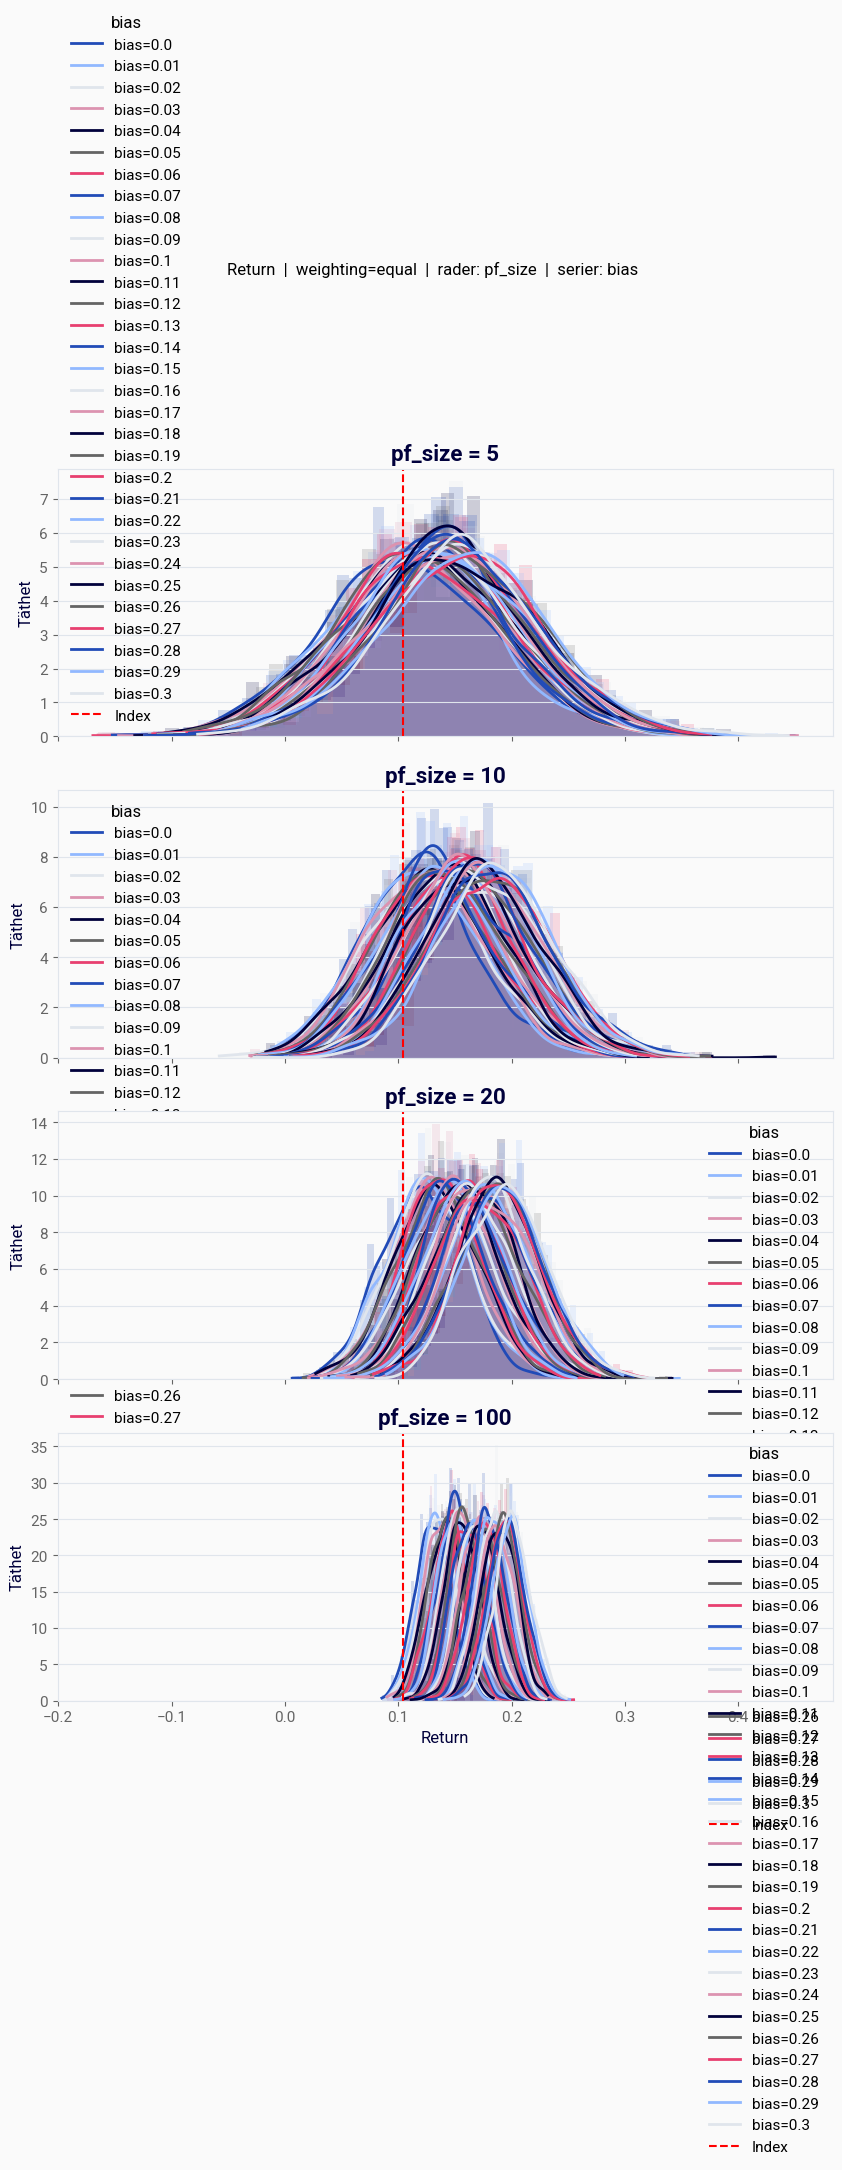

In [106]:
from scipy.stats import gaussian_kde

# ── Inställningar ────────────────────────────────────────────────────────
kf        = 'Return'
fixed_dim = ('weighting', 'equal')    # (dimension, värde) som hålls fast
row_dim   = 'pf_size'                 # en rad per portföljstorlek
chart_dim = 'bias'                    # en serie per bias-nivå

_dim_values = {
    'bias':      MC_BIASES,
    'weighting': MC_WEIGHTINGS,
    'pf_size':   MC_PF_SIZES,
}
row_values   = _dim_values[row_dim]
chart_values = _dim_values[chart_dim]
fixed_level, fixed_val = fixed_dim

_level_order = list(mc_result.index.names)  # ['bias','weighting','pf_size','metric']

def _get_vals(row_val, chart_val):
    selector = {
        row_dim:     row_val,
        chart_dim:   chart_val,
        fixed_level: fixed_val,
        'metric':    kf,
    }
    key = tuple(selector[lvl] for lvl in _level_order)
    try:
        vals = mc_result.loc[key]
        if isinstance(vals, pd.DataFrame):
            vals = vals.squeeze()
        return vals.dropna().astype(float)
    except KeyError:
        return pd.Series(dtype=float)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(
    len(row_values), 1,
    figsize=(10, 4 * len(row_values)),
    sharex=True
)
if len(row_values) == 1:
    axes = [axes]

for ax, row_val in zip(axes, row_values):
    for ci, chart_val in enumerate(chart_values):
        vals = _get_vals(row_val, chart_val)
        if len(vals) < 2:
            continue
        color = colors[ci % len(colors)]
        label = f'bias={chart_val}'
        ax.hist(vals, bins=40, alpha=0.18, color=color, density=True)
        kde = gaussian_kde(vals)
        x   = np.linspace(vals.min(), vals.max(), 300)
        ax.plot(x, kde(x), color=color, linewidth=2, label=label)

    ax.axvline(bench_kfs[kf], color='red', linestyle='--', linewidth=1.5, label='Index')
    ax.set_title(f'{row_dim} = {row_val}', fontweight='bold')
    ax.set_ylabel('Täthet')
    ax.legend(title=chart_dim, framealpha=0.7)

axes[-1].set_xlabel(kf)
fig.suptitle(
    f'{kf}  |  {fixed_level}={fixed_val}  |  rader: {row_dim}  |  serier: {chart_dim}',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

## 6. Hur mycket bias krävs för att en koncentrerad portfölj ska matcha en diversifierad?

Vi söker den bias-nivå där en 10-aktieportfölj når samma **certainty equivalent** som en 100-aktieportfölj vid bias=0 (oselekterad benchmark).

$$CE = \mu - \frac{\lambda}{2} \cdot \sigma^2$$

där μ och σ² är medianen respektive variansen av annualiserad avkastning och volatilitet över MC-körningarna. Riskaversionsparametern λ styr avvägningen mellan avkastning och risk.

Jämför: 5-aktier vs referens 100-aktier (bias=0)


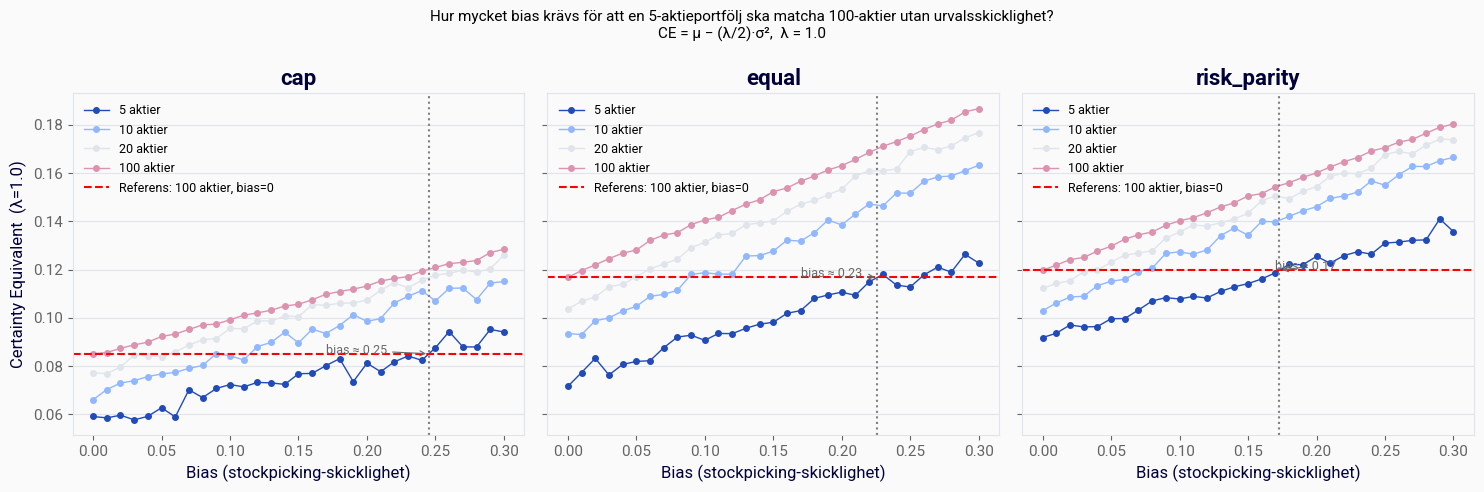


Bias-nivå där 5-aktieportfölj ≈ 100-aktieportfölj (bias=0), λ=1.0:
                         cap  equal  risk_parity
Crossover bias (pf=5)  0.245  0.226        0.173


In [107]:
RISK_AVERSION = 1.0  # λ — ändra här för känslighetsanalys

# Minsta och referens-portföljstorlek (anpassas automatiskt till tillgänglig data)
PF_SMALL = MC_PF_SIZES[0]   # t.ex. 5 eller 10
PF_REF   = MC_PF_SIZES[-1]  # t.ex. 100
print(f'Jämför: {PF_SMALL}-aktier vs referens {PF_REF}-aktier (bias=0)')


def median_ce(bias, pf_size, weighting, lam=RISK_AVERSION):
    """Median CE = E[r] − (λ/2)·Var[r] över MC-körningarna."""
    try:
        ret = mc_result.xs(
            (bias, weighting, pf_size, 'Return'),
            level=['bias', 'weighting', 'pf_size', 'metric']
        )
        vol = mc_result.xs(
            (bias, weighting, pf_size, 'Vol'),
            level=['bias', 'weighting', 'pf_size', 'metric']
        )
        if ret.empty or vol.empty:
            return np.nan
        r = ret.iloc[0].dropna().astype(float)
        v = vol.iloc[0].dropna().astype(float)
        return (r - (lam / 2) * v**2).median()
    except (KeyError, IndexError):
        return np.nan


def find_crossover(ces_small, reference, biases):
    """Linjär interpolation: bias där ces_small korsas med reference."""
    for i in range(len(biases) - 1):
        y0, y1 = ces_small[i], ces_small[i + 1]
        if np.isnan(y0) or np.isnan(y1):
            continue
        if (y0 - reference) * (y1 - reference) <= 0:
            t = (reference - y0) / (y1 - y0) if y1 != y0 else 0.0
            return biases[i] + t * (biases[i + 1] - biases[i])
    return np.nan


# Dynamisk färgmappning
_palette = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors_sz = {sz: _palette[i % len(_palette)] for i, sz in enumerate(MC_PF_SIZES)}

fig, axes = plt.subplots(1, len(MC_WEIGHTINGS), figsize=(15, 5), sharey=True)
crossover_table = {}

for ax, wgt in zip(axes, MC_WEIGHTINGS):
    ref = median_ce(0.0, PF_REF, wgt)

    for sz in MC_PF_SIZES:
        ces = [median_ce(b, sz, wgt) for b in MC_BIASES]
        ax.plot(MC_BIASES, ces, marker='o', markersize=4,
                color=colors_sz[sz], label=f'{sz} aktier')

    ax.axhline(ref, color='red', linestyle='--', linewidth=1.5,
               label=f'Referens: {PF_REF} aktier, bias=0')

    ces_small = [median_ce(b, PF_SMALL, wgt) for b in MC_BIASES]
    xover = find_crossover(ces_small, ref, MC_BIASES)
    crossover_table[wgt] = round(xover, 3) if not np.isnan(xover) else '—'

    if not np.isnan(xover):
        ax.axvline(xover, color='grey', linestyle=':', linewidth=1.5)
        ax.annotate(
            f'bias ≈ {xover:.2f}',
            xy=(xover, ref),
            xytext=(min(xover + 0.02, 0.17), ref),
            fontsize=9, color='dimgrey',
            arrowprops=dict(arrowstyle='->', color='dimgrey', lw=0.8),
        )

    ax.set_title(wgt, fontweight='bold')
    ax.set_xlabel('Bias (stockpicking-skicklighet)')
    ax.legend(fontsize=9, loc='upper left')

axes[0].set_ylabel(f'Certainty Equivalent  (λ={RISK_AVERSION})')
fig.suptitle(
    f'Hur mycket bias krävs för att en {PF_SMALL}-aktieportfölj ska matcha {PF_REF}-aktier utan urvalsskicklighet?\n'
    f'CE = μ − (λ/2)·σ²,  λ = {RISK_AVERSION}',
    fontsize=11,
)
plt.tight_layout()
plt.show()

print(f'\nBias-nivå där {PF_SMALL}-aktieportfölj ≈ {PF_REF}-aktieportfölj (bias=0), λ={RISK_AVERSION}:')
print(pd.DataFrame({f'Crossover bias (pf={PF_SMALL})': crossover_table}).T.to_string())

## 7. Risk–avkastningsprofil per viktning

Scatter-plot med **volatilitet** (x) och **avkastning** (y) baserade på median över 1000 MC-körningar. Färgen visar bias-nivån (colorbar) och markörformen visar portföljstorleken.

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Colormap: bias styr färgen
cmap = cm.plasma
bias_arr = np.array(MC_BIASES, dtype=float)
norm = mcolors.Normalize(vmin=bias_arr.min(), vmax=bias_arr.max())

# Markörform per portföljstorlek
_marker_shapes = ['o', 's', '^', 'D', 'v', 'P', 'X', 'h']
_marker_sizes  = [50, 80, 110, 140, 170, 200, 230, 260]
markers  = {sz: _marker_shapes[i % len(_marker_shapes)] for i, sz in enumerate(MC_PF_SIZES)}
msizes   = {sz: _marker_sizes[i % len(_marker_sizes)]   for i, sz in enumerate(MC_PF_SIZES)}

fig, axes = plt.subplots(1, len(MC_WEIGHTINGS), figsize=(6 * len(MC_WEIGHTINGS) + 1, 5),
                         sharey=True)

for ax, wgt in zip(axes, MC_WEIGHTINGS):
    for sz in MC_PF_SIZES:
        med_vols, med_rets, bias_vals = [], [], []

        for bias in MC_BIASES:
            try:
                ret_row = mc_result.xs(
                    (bias, wgt, sz, 'Return'),
                    level=['bias', 'weighting', 'pf_size', 'metric']
                )
                vol_row = mc_result.xs(
                    (bias, wgt, sz, 'Vol'),
                    level=['bias', 'weighting', 'pf_size', 'metric']
                )
                if ret_row.empty or vol_row.empty:
                    continue
                med_rets.append(ret_row.iloc[0].dropna().astype(float).median())
                med_vols.append(vol_row.iloc[0].dropna().astype(float).median())
                bias_vals.append(float(bias))
            except (KeyError, IndexError):
                continue

        if not med_vols:
            continue

        ax.scatter(
            med_vols, med_rets,
            c=bias_vals, cmap=cmap, norm=norm,
            marker=markers[sz], s=msizes[sz],
            label=f'{sz} aktier',
            edgecolors='white', linewidths=0.5, zorder=3,
        )

    # Benchmark-punkt
    ax.scatter(
        [bench_kfs['Vol']], [bench_kfs['Return']],
        marker='*', s=250, color='red', zorder=5, label='Index'
    )

    ax.set_title(wgt, fontweight='bold')
    ax.set_xlabel('Volatilitet (median över MC-körningar)')
    ax.legend(fontsize=9, loc='lower right', title='Portföljstorlek')

axes[0].set_ylabel('Avkastning (median över MC-körningar)')

# Gemensam colorbar för bias
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), orientation='vertical',
                    fraction=0.015, pad=0.02)
cbar.set_label('Bias (stockpicking-skicklighet)', fontsize=10)

fig.suptitle(
    'Risk–avkastningsprofil  |  färg = bias  |  markör = portföljstorlek',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

## 8. Erforderlig bias per portföljstorlek och riskaversion

Tabeller (en per viktning) som visar hur mycket bias som krävs för att en portfölj av given storlek ska nå samma certainty equivalent som en `PF_REF`-aktieportfölj utan urvalsskicklighet (bias=0).

In [ ]:
LAMBDA_VALS = [0.5, 1.0, 2.0]

def crossover_bias(pf_size, weighting, lam):
    """
    Minsta bias där pf_size-portföljen når samma CE som PF_REF vid bias=0.
    Returnerar float eller NaN om ingen korsning hittas inom bias-intervallet.
    """
    ref = median_ce(0.0, PF_REF, weighting, lam=lam)
    if np.isnan(ref):
        return np.nan
    ces = [median_ce(b, pf_size, weighting, lam=lam) for b in MC_BIASES]
    return find_crossover(ces, ref, MC_BIASES)


for wgt in MC_WEIGHTINGS:
    rows = {}
    for sz in MC_PF_SIZES:
        if sz == PF_REF:
            rows[sz] = {lam: 0.0 for lam in LAMBDA_VALS}
            continue
        rows[sz] = {}
        for lam in LAMBDA_VALS:
            xover = crossover_bias(sz, wgt, lam)
            rows[sz][lam] = xover

    tbl = pd.DataFrame(rows, index=LAMBDA_VALS).T
    tbl.index.name   = 'Portföljstorlek'
    tbl.columns.name = 'Riskaversion (λ)'
    tbl.columns      = [f'λ = {l}' for l in LAMBDA_VALS]

    def _fmt(v):
        if np.isnan(v):
            return '> max'
        if v == 0.0:
            return '— (referens)'
        return f'{v:.3f}'

    print(f'\n{"─"*50}')
    print(f'Viktning: {wgt}')
    print(f'Bias-nivå för att matcha {PF_REF}-aktieportfölj (bias=0)')
    print(f'{"─"*50}')
    print(tbl.applymap(_fmt).to_string())
print()

## 9. Erforderlig bias för att matcha benchmark (cap-viktad)

Samma upplägg som sektion 8, men referensnivån är **benchmarkindexets** certainty equivalent snarare än den diversifierade portföljens.

In [ ]:
WGT_FOCUS = 'cap'

rows = {}
for sz in MC_PF_SIZES:
    rows[sz] = {}
    for lam in LAMBDA_VALS:
        # Benchmark CE för denna riskaversion
        bench_ce = bench_kfs['Return'] - (lam / 2) * bench_kfs['Vol'] ** 2

        # CE-kurva för portföljstorleken som funktion av bias
        ces = [median_ce(b, sz, WGT_FOCUS, lam=lam) for b in MC_BIASES]

        rows[sz][lam] = find_crossover(ces, bench_ce, MC_BIASES)

tbl = pd.DataFrame(rows, index=LAMBDA_VALS).T
tbl.index.name = 'Portföljstorlek'
tbl.columns    = [f'λ = {l}' for l in LAMBDA_VALS]

def _fmt(v):
    if np.isnan(v):
        return '> max'
    return f'{v:.3f}'

print(f'Viktning: {WGT_FOCUS}')
print(f'Bias-nivå för att matcha benchmark CE')
print()
print(tbl.applymap(_fmt).to_string())

Viktning: cap
Bias-nivå för att matcha benchmark CE

                λ = 0.5 λ = 1.0 λ = 2.0
Portföljstorlek                        
5                 0.169   0.253   > max
10                0.087   0.128   0.187
20                0.061   0.073   0.098
100               0.032   0.036   0.045


C:\Users\JonasAnderssonTuomaa\AppData\Local\Temp\ipykernel_16452\62969251.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(tbl.applymap(_fmt).to_string())
